In [11]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sys
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = "Nord"  # "Nord" or "ExtNord"

ΤARGET = "_ovr5"  # "_und5", "_ovr5", "_prgn", "_severe", "hospitalization" or ""

In [12]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', encoding=enc)

In [13]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [14]:
dataframe.drop(columns=['Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 
                        'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 
                        'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

In [15]:
dataframe.drop(columns=['Case_UND5', 
                        #'Case_OVR5', 
                        'Case_PRGN', 
                        'Case_TOTAL',
                        'Sevr_TOTAL',
                        'Hosp_TOTAL'], inplace=True)


dataframe.rename(columns={'Case_OVR5': 'cases'}, inplace=True)

In [16]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [17]:
# dataframe = dataframe[dataframe["dt_prediction"] <= pd.Period("2023-12", freq="M")]
# dataframe.reset_index(drop=True, inplace=True)

# dataframe.head()

In [18]:
print(dataframe.dt_prediction.min())
print(dataframe.dt_prediction.max())

2014-10
2024-09


In [19]:
with open(f'saved/CM_{REGION}_bin_ranges{ΤARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

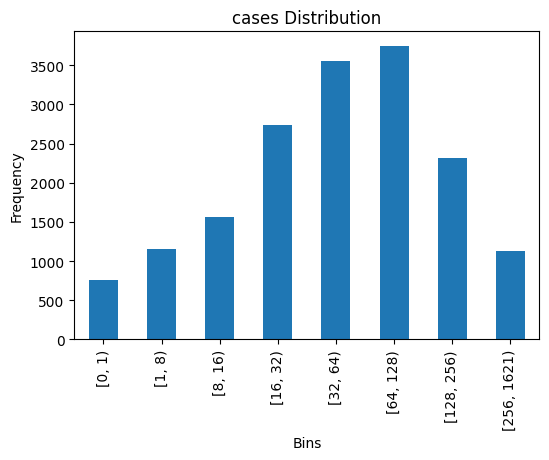

In [20]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(6, 4), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [21]:
num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 8


In [22]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7]

In [23]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [24]:
dataframe['case_bin'] = bins

In [25]:
dataset = dataframe.copy()

In [26]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [27]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256 1621]


In [28]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [29]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [30]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [31]:
with open(f"saved/CM_{REGION}_rfecv_model{ΤARGET}.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [32]:
with open(f"saved/CM_{REGION}_gridcv_best_params{ΤARGET}.json", "r") as f:
    model_params = json.load(f)

In [33]:
X_train = X.copy()
y_train = y.copy()

In [34]:
scaler = StandardScaler()
fitted_scaler = scaler.fit(X_train)
X_train_scaled = pd.DataFrame(fitted_scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

In [35]:
imputer = KNNImputer(n_neighbors=3)
fitted_imputer = imputer.fit(X_train_scaled)
X_train_imputed = pd.DataFrame(fitted_imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)

In [36]:
X_train_imputed = pd.DataFrame(fitted_scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)

X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)

In [37]:
X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)

In [38]:
model = xgb.XGBRegressor(**model_params)   
fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

In [39]:
with open(f'saved/CM_{REGION}_scaler{ΤARGET}.pkl', 'wb') as f:
    pickle.dump(fitted_scaler, f)

In [40]:
with open(f'saved/CM_{REGION}_imputer{ΤARGET}.pkl', 'wb') as f:
    pickle.dump(fitted_imputer, f)

In [41]:
with open(f'saved/CM_{REGION}_xgb_model{ΤARGET}.pkl', 'wb') as f:
    pickle.dump(fitted_model, f)